# Exploration of various datasets

This notebook explores the renderings of the AugmentedDataset and the transformations used.
## MNIST

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
from g_invariance import dataset
import torchvision.transforms as torchvision_transforms

transform = torchvision_transforms.Compose(
    [
        torchvision_transforms.ToTensor(),
        # TODO: Some issues when size changes. Understand why.
        torchvision_transforms.Resize((16,)),
        torchvision_transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(img.numpy().squeeze(), cmap='gray_r')

100%|██████████| 9912422/9912422 [00:00<00:00, 100470290.17it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 54614830.40it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 53415291.07it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 5407473.39it/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

Data augmentation...
Saving data to data/MNIST_data_so2_2_random_train.npy and data/MNIST_labels_so2_2_random_train.npy...


/home/johmathe/miniconda3/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


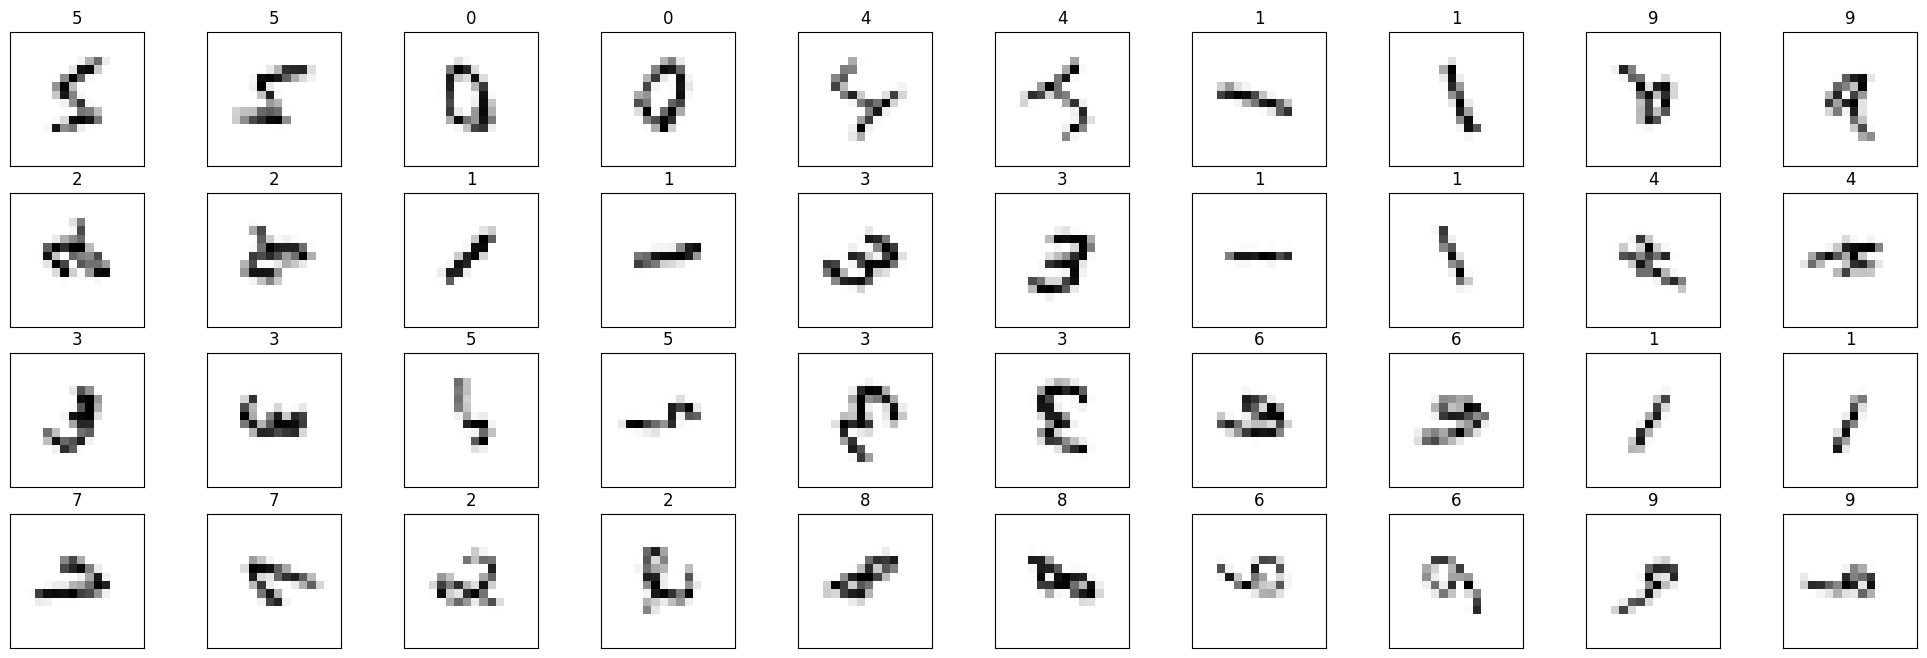

In [2]:

# Download and load the training data
images = dataset.AugmentedDataset('data/', train=True, transform=transform)

# Select a few images to display
num_images = 40
fig = plt.figure(figsize=(25, 8))
for idx in range(num_images):
    image, label = images[idx]  # Access the image and its corresponding label directly

    ax = fig.add_subplot(4, 10, idx+1, xticks=[], yticks=[])
    imshow(image)
    ax.set_title(label)

# EMNIST

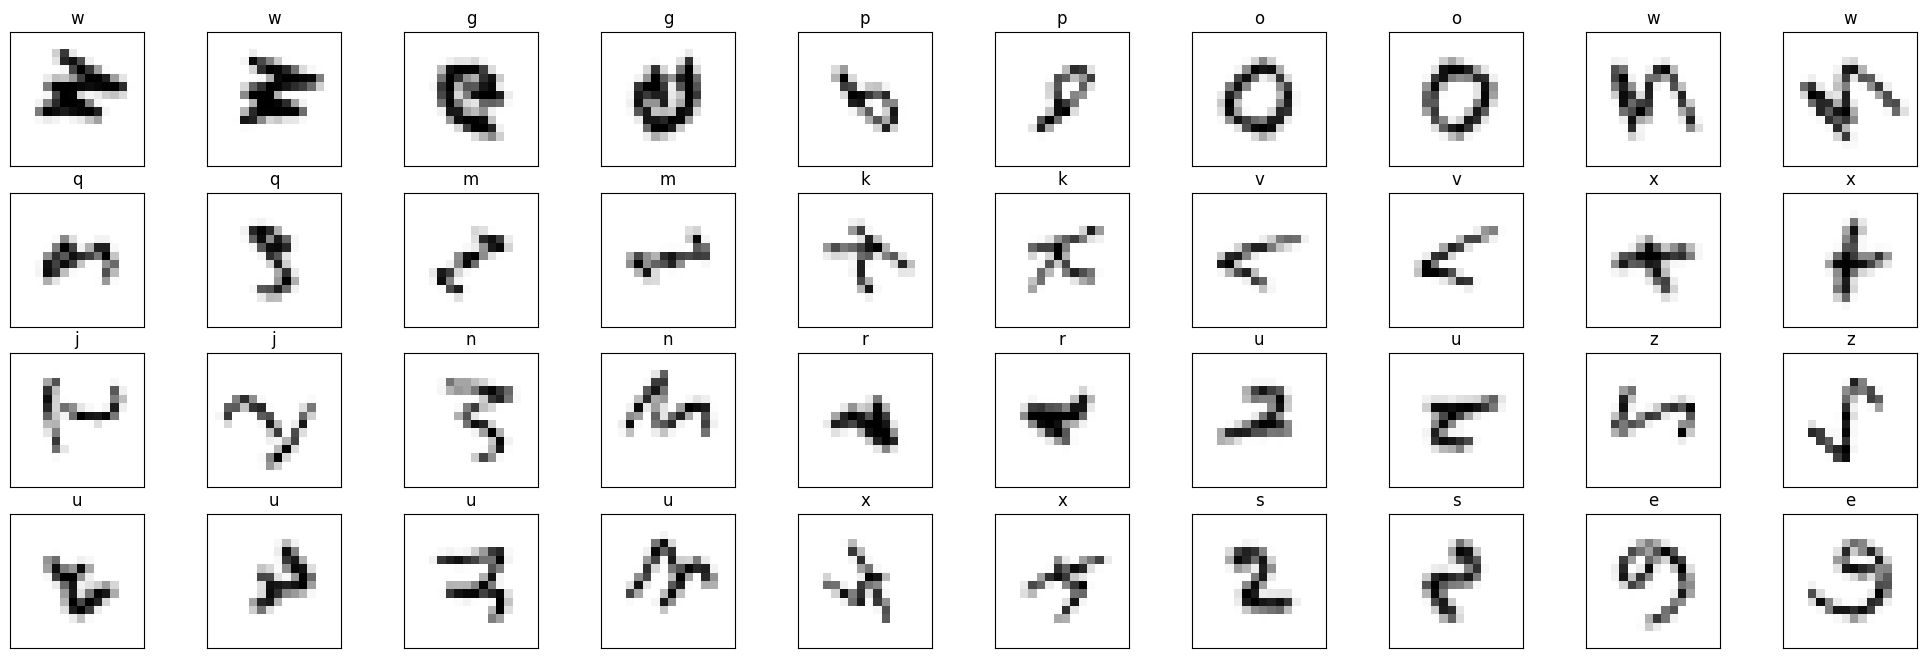

In [15]:
# Select a few images to display
images = dataset.AugmentedDataset('data', train=True, transform=transform, dataset_name='EMNIST')

# Select a few images to display
num_images = 40
fig = plt.figure(figsize=(25, 8))
for idx in range(num_images):
    image, label = images[idx]  # Access the image and its corresponding label directly

    ax = fig.add_subplot(4, 10, idx+1, xticks=[], yticks=[])
    imshow(image)
    ax.set_title(chr(97 + label))

TypeError: Invalid shape (3, 16, 16) for image data

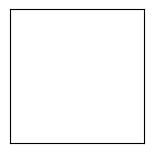

In [4]:

# CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Load the CIFAR10 dataset
images = dataset.AugmentedDataset('data', train=True, transform=transform, dataset_name='CIFAR10')

# Function to show an image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))
    plt.axis('off')  # Turn off axis numbers and ticks

# Display images
num_images = 40
fig = plt.figure(figsize=(25, 8))
for idx in range(num_images):
    image, label = images[idx]  # Access the image and its corresponding label directly
    ax = fig.add_subplot(4, 10, idx+1, xticks=[], yticks=[])
    imshow(image)
    ax.set_title(classes[label])